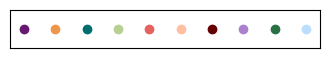

In [1]:
# Read packages and general stuff
import cobra
import sys
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import ast
from matplotlib import font_manager
from scipy.stats import pearsonr
from statsmodels.stats.multitest import multipletests
from adjustText import adjust_text
sys.path.append('../')
from modelfunctions import *

wd = os.path.abspath(os.getcwd()).removesuffix('Code/modelComparison')
figdir = wd + 'Figures/'

# use Arial
try: 
    font_path = '/home/emil/.fonts/ARIAL.TTF'  # Your font path goes here
    font_manager.fontManager.addfont(font_path)
    prop = font_manager.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = 'sans-serif'
    plt.rcParams['font.sans-serif'] = prop.get_name()
except:
    print('Arial font not found, using default')

# define colors, plotting params
colors = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70), (0xee, 0x96, 0x4b), 
 (0xb6,0xd0, 0x94), (0x66, 0x00, 0x00), (0xab, 0x81, 0xcd), (0x00, 0x6d, 0x6f),
 (0xe5, 0x62, 0x5e), (0xba, 0xde, 0xfc), (0x87, 0x8e, 0x99), (0x29, 0x70, 0x45),
 (0xff, 0xbf, 0xa0)]]
cols_opt_order = [(r/0xff, g/0xff, b/0xff) for r,g,b in [(0x67, 0x19, 0x70),
 (0xee, 0x96, 0x4b), (0x0, 0x6d, 0x6f), (0xb6, 0xd0, 0x94), (0xe5, 0x62, 0x5e),
 (0xff, 0xbf, 0xa0), (0x66, 0x0, 0x0), (0xab, 0x81, 0xcd), (0x29, 0x70, 0x45),
 (0xba, 0xde, 0xfc)]]

fig_sizes = (6, 4)
models_transl = {'aracore': 'AraCore', 'aragem': 'AraGEM', 'sweetlove': 'CAM', 'maize': 'Maize',
                'rice': 'Rice', 'mintzOron': 'Mintz-Oron', 'panAlgae': 'Pan-Algae',
                'poplar': 'Poplar', 'soy': 'Soybean', 'potato': 'Potato', 'pcm': 'PCM',
                'Sobliquus': 'S. obliquus', 'Cohadii': 'C. ohadii', 'cam': 'CAM'}

plt.figure(figsize = (4,0.5))
for i, colo in enumerate(cols_opt_order):
    plt.plot([i], 0, 'o', color=colo)
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
plt.show()

In [2]:
plt.rcParams.update({'font.size': 15})

### a

Number of pcm pan genes: 23830


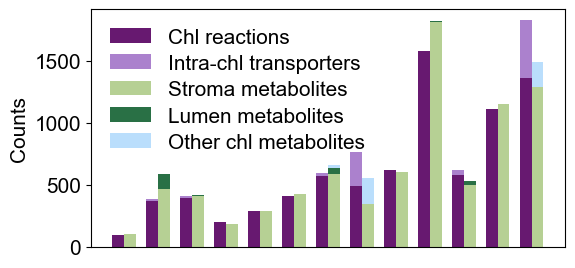

In [4]:
# Sort models so that for the ec evidence plots, they are sorted, and for the others, the legend is not obstructed
models_in_order = ['aragem', 'Cohadii', 'cam', 'aracore', 'soy', 
                   'Sobliquus', 'panAlgae', 'potato', 'mintzOron',
                   'poplar', 'rice', 'maize', 'pcm']

def sort_models(data):
    model_comp_order = [m if m != 'cam' else 'sweetlove' for m in models_in_order]
    return data.set_index('model_name').loc[model_comp_order].reset_index()

def comp_plot(data_fname, fig_fname, include_transports = True, xax_label = True, xax_label_text = True):

    # Load the CSV data into a Pandas DataFrame
    data = pd.read_csv(data_fname)
    print('Number of pcm pan genes:', data['nPanGenes'].iloc[-1].item())
    
    # Sort algae to the front (mostly so the legend does not obscure anything) and pcm as last
    data = sort_models(data)
    col_palette = cols_opt_order

    # Prepare data for the stacked bar plot
    models = data['model_name']
    nChlRxns = data['nChlRxns']
    nTransp = data['nTransp']
    nIntraChlTransp = data['nIntraChlTransp']
    nMetsStroma = data['nMetsStroma']
    nMetsThylLum = data['nMetsThylLum']
    nMetsChl_extra = data['nMetsChl'] - nMetsStroma - nMetsThylLum
    nGenes = data['nGenes']

    # Set up bar width and figure sizing
    barWidth = 0.35
    fig, ax = plt.subplots(figsize=fig_sizes if xax_label else (fig_sizes[0], fig_sizes[1] * 0.735))

    # Positions for the bars
    r1 = np.arange(len(models))
    r2 = [x + barWidth for x in r1]

    # Plot each set of bars for stacked components
    ax.bar(r1, nChlRxns, color=col_palette[0], width=barWidth, label='Chl reactions')
    ax.bar(r1, nIntraChlTransp, bottom=nChlRxns, color=col_palette[7], width=barWidth, label='Intra-chl transporters')
    if include_transports:
        ax.bar(r1, nTransp, bottom=nChlRxns + nIntraChlTransp, color=col_palette[1], width=barWidth, label='Chl-cyt transporters')

    #ax.bar(r3[-1], pcmPanGenes, color=tuple(0.8* c for c in col_palette[6]), width=barWidth, label=None)
    #ax.bar(r3, nGenes, color=col_palette[6], width=barWidth, label='Number of genes')

    ax.bar(r2, nMetsStroma, color=col_palette[3], width=barWidth, label='Stroma metabolites')
    ax.bar(r2, nMetsThylLum, bottom=nMetsStroma, color=col_palette[8], width=barWidth, label='Lumen metabolites')
    ax.bar(r2, nMetsChl_extra, bottom=nMetsStroma + nMetsThylLum, color=col_palette[9], width=barWidth, label='Other chl metabolites')

    # Add tick labels and titles
    ax.set_xticks([r + (barWidth * 0.5) for r in range(len(models))])
    ax.set_xticklabels([models_transl[modelID] for modelID in models], rotation=30, ha="right")
    if xax_label:
        if xax_label_text:
            ax.set_xlabel('Chloroplast Models')
    else:
        ax.tick_params(bottom=False, labelbottom=False)
    ax.set_ylabel('Counts')

    # legend
    ax.legend(loc='upper left', ncol=1, frameon=False, labelspacing = 0.35)

    plt.tight_layout()
    plt.savefig(fig_fname, dpi=300, transparent = True)
    plt.show()

    return data

data_fname = f'{wd}Data/analysis/modelComparison/modelComparison.csv'
data = comp_plot(data_fname, figdir + 'modelComparison_main.png', include_transports=False, xax_label=False)

In [5]:
data.sort_values('nGenes')

,model_name,nChlRxns,totModelRxns,nTransp,nIntraChlTransp,nMetsStroma,nMetsThylLum,nMetsChl,nGenes,nSubsystems,nChloroplastComps,chlComps,nPanGenes
0,aragem,93,1601,31,0,105,0,105,168,0,1,p,0
1,Cohadii,366,2516,183,15,463,122,585,244,258,2,"ch,th",0
3,aracore,195,585,60,5,182,1,183,372,53,2,"h,l",0
5,Sobliquus,409,1467,142,1,423,0,423,390,0,1,d0,0
2,sweetlove,396,1312,120,9,412,2,414,583,65,4,"p1,p2,l1,l2",0
7,potato,487,7092,311,277,341,1,553,610,0,5,"h,hm,ohm,pg,l",0
6,panAlgae,570,788,95,21,582,54,660,774,66,3,"h,s,u",0
10,rice,577,2444,118,41,500,27,527,880,53,2,"s,u",0
8,mintzOron,617,2769,177,0,600,0,600,920,133,1,Plastid,0
4,soy,286,3001,79,0,290,0,290,1168,0,1,p,0


### b

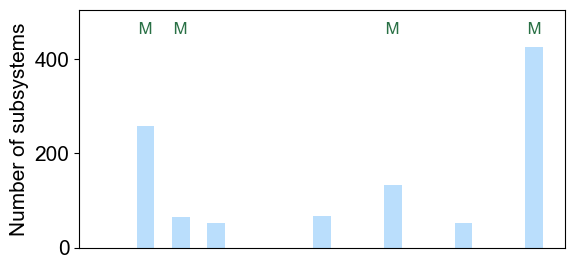

In [6]:
def comp_groups_plot(data_fname, fig_fname, xax_label = True,
                     add_mc_marker = ['sweetlove', 'Cohadii', 'mintzOron', 'pcm']):

    # Simple bar plot for nGenes

    # Load the CSV data into a Pandas DataFrame
    data = pd.read_csv(data_fname)
    
    # Sort algae to the front (mostly so the legend does not obscure anything)
    data = data = sort_models(data)
    col_palette = colors

    # Prepare data for the stacked bar plot
    models = data['model_name']

    # Simple bar plot for nSubsystems
    fig, ax = plt.subplots(figsize=fig_sizes if xax_label else (fig_sizes[0], fig_sizes[1] * 0.735))
    ax.bar(models, data['nSubsystems'], color=col_palette[7], width=0.5)
    ax.set_ylabel('Number of subsystems')
    ax.set_xticks([r for r in range(len(models))])
    ax.set_xticklabels([models_transl[modelID] for modelID in models], rotation=30, ha="right")
    if xax_label:
        ax.set_xlabel('Chloroplast Models')
    else:
        ax.tick_params(bottom=False, labelbottom=False)

    if add_mc_marker:
        y_marker = max(data['nSubsystems'].iloc[i] for i, model in enumerate(models) if model in add_mc_marker) + 20
        for i, model in enumerate(models):
            if model in add_mc_marker:
                ax.text(i, y_marker, ' M ', ha='center', va='bottom', fontsize=12, color=cols_opt_order[8])
    
    ax.set_ylim(0, y_marker * 1.13)

    plt.tight_layout()
    plt.savefig(fig_fname, dpi=300, transparent = True)
    plt.show()

comp_groups_plot(data_fname, figdir + 'modelComparison_subSystems.png', xax_label=False)

### c

In [7]:
import_version = 1
pcm = cobra.io.read_sbml_model(f'{wd}Data/pcm/pcm.v{import_version}.xml')

# data of the different models
final_df = pd.read_csv(wd + 'Data/analysis/modelComparison/comparison_data_extended.csv', index_col=0, dtype={'is_transp': bool,
                                                                                           'in_pcm': bool,
                                                                                           'max_evid': np.int64,
                                                                                           'evid_brenda': np.bool_})
for col in final_df:
    if col in ['model_id', 'ec', 'inChlVirid', 'uniprGpr', 'model_gpr']:
        final_df[col] = final_df[col].apply(ast.literal_eval)
    elif col not in ['is_transp', 'in_pcm', 'max_evid', 'evid_brenda']:
        final_df[col] = final_df[col].fillna('').astype(str)

# brenda data
with open(wd + 'Data/analysis/modelComparison/res_brenda.txt', 'r') as file:
    res_brenda = ast.literal_eval(file.read())

# uniprot data
with open(wd + 'Data/analysis/modelComparison/uniprot_ecs_dict.txt', 'r') as file:
    ec_res = ast.literal_eval(file.read())

Set parameter Username
Set parameter LicenseID to value 2694489
Academic license - for non-commercial use only - expires 2026-08-08


In [8]:
# use the collected data to make a plot comparing the number of unique EC numbers in the models
final_df['model_unique'] = final_df['model'].str.split(', ').apply(lambda ls: list(set(ls)))
mec = final_df.explode('model_unique').groupby('model_unique')['ec'].agg('sum').map(set)

# update mec
# obtain the ECs from PCM from the model directly
pcm_ecs = set()
for r in pcm.reactions:
    if 'ec-code' in r.annotation:
        curr_ecs = r.annotation['ec-code']
        if type(curr_ecs) is str:
            pcm_ecs = pcm_ecs.union(r.annotation['ec-code'].split(','))
        elif type(curr_ecs) is list:
            pcm_ecs = pcm_ecs.union(curr_ecs)
        else:
            print('unkown type:', curr_ecs)
pcm_ecs = {ec.strip() for ec in pcm_ecs if ec.strip()}
mec['pcm'] = pcm_ecs

In [9]:
# are there any ECs for which we have evidence, but that is not in the pcm?
# How high is the percentage of EC numbers in the models with/without/which DB to have evidence for?
# stacked bar for each model to answer both
res_uniprot = {ec: ec_res[ec][0] > 0 for ec in ec_res}
all_ecs = set(mec.apply(list).sum())
res = {}
for org in mec.index:
    res[org] = {}
    for ec in all_ecs:
        in_org = ec in mec[org]
        br = res_brenda[ec] if ec in res_brenda else False
        uni = res_uniprot[ec] if ec in res_uniprot else False
        res[org][(in_org, br + uni)] =  res[org].get((in_org, br + uni), set()).union([ec])

plot_vals = pd.DataFrame(res).map(len)
sorted_idx = plot_vals.loc[True].T.sort_values(2).index
plot_vals = plot_vals.loc[:, sorted_idx.to_list()]

Light: Not in the model, dark: In the model


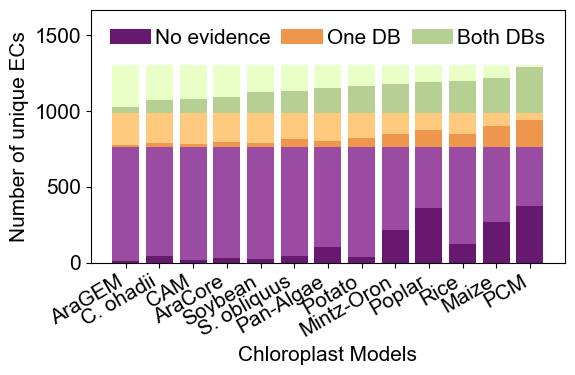

In [10]:
def ec_overview(plot_vals, fig_fname, xax_label = True):
    # Set up bar width and figure sizing
    col_palette = colors
    col_diff = 0.2
    barWidth = 0.8
    fig, ax = plt.subplots(figsize=fig_sizes if xax_label else (fig_sizes[0], fig_sizes[1] * 0.735))

    # Positions for the bars
    r1 = np.arange(plot_vals.shape[1])

    # sort model positions
    plot_vals = plot_vals[models_in_order]

    # Plot stacked bars
    curr_val = plot_vals.loc[(True, 0)]
    ax.bar(r1, curr_val, color=col_palette[0], width=barWidth, label='No evidence')
    curr_bot = curr_val
    curr_val = plot_vals.loc[(False, 0)]
    ax.bar(r1, curr_val, bottom = curr_bot, color=tuple(min(1, c + col_diff) for c in col_palette[0]), width=barWidth)
    curr_bot = curr_bot + curr_val
    curr_val = plot_vals.loc[(True, 1)]
    ax.bar(r1, curr_val, bottom = curr_bot, color=col_palette[1], width=barWidth, label='One DB')
    curr_bot = curr_bot + curr_val
    curr_val = plot_vals.loc[(False, 1)]
    ax.bar(r1, curr_val, bottom = curr_bot, color=tuple(min(1, c + col_diff) for c in col_palette[1]), width=barWidth)
    curr_bot = curr_bot + curr_val
    curr_val = plot_vals.loc[(True, 2)]
    ax.bar(r1, curr_val, bottom = curr_bot, color=col_palette[2], width=barWidth, label='Both DBs')
    curr_bot = curr_bot + curr_val
    curr_val = plot_vals.loc[(False, 2)]
    ax.bar(r1, curr_val, bottom = curr_bot, color=tuple(min(1, c + col_diff) for c in col_palette[2]), width=barWidth)

    # Add tick labels and titles
    ax.set_xticks([r + (barWidth * 0) for r in range(len(plot_vals.columns))])
    ax.set_xticklabels([models_transl[modelID] for modelID in plot_vals.columns], rotation=30, ha="right")
    if xax_label:
        ax.set_xlabel('Chloroplast Models')
    else:
        ax.tick_params(bottom=False, labelbottom=False)
    ax.set_ylabel('Number of unique ECs')
    ax.set_ylim(0, ax.get_ylim()[1] + 300)
    #ax.set_title('Stacked Bar Plot for Model Attributes')
    ax.legend(loc='upper left', ncol=3, frameon = False, columnspacing = 0.5, handletextpad = 0.2)

    plt.tight_layout()
    plt.savefig(figdir + fig_fname, dpi=300, transparent = True)
    print('Light: Not in the model, dark: In the model')
    plt.show()
ec_overview(plot_vals, 'ec_evid_ratio.png', xax_label = True)

In [11]:
(plot_vals.loc[(True, 0)] / plot_vals.loc[True].sum()).sort_values()

soy          0.110526
cam          0.113821
potato       0.144444
aragem       0.164179
Sobliquus    0.176471
aracore      0.190751
Cohadii      0.289308
rice         0.295400
panAlgae     0.323625
maize        0.416667
pcm          0.436768
mintzOron    0.439673
poplar       0.533432
dtype: float64

### d

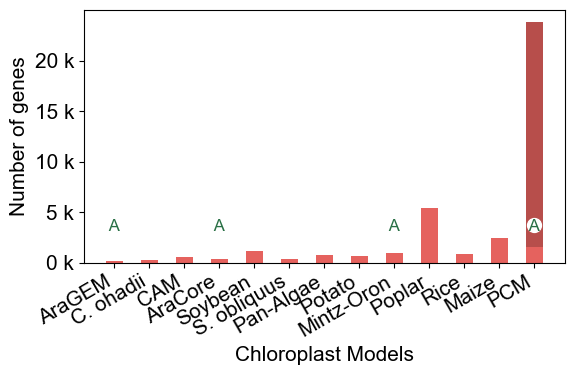

In [12]:
def comp_genes_plot(data_fname, fig_fname, xax_label = True,
                    add_ara_marker = ['aracore', 'aragem', 'mintzOron', 'pcm']):
    # Simple bar plot for nGenes

    # Load the CSV data into a Pandas DataFrame
    data = pd.read_csv(data_fname)
    
    # Sort algae to the front (mostly so the legend does not obscure anything)
    data = sort_models(data)
    col_palette = colors

    # Prepare data for the stacked bar plot
    pcmPanGenes = data['nPanGenes']
    models = data['model_name']
    nGenes = data['nGenes']

    fig, ax = plt.subplots(figsize=fig_sizes if xax_label else (fig_sizes[0], fig_sizes[1] * 0.735))
    #ax2.bar(models, data['nSubsystems'], color=col_palette[7], width=barWidth*2)
    #ax2.set_xlabel('Model Name')

    barWidth = 0.5
    r1 = np.arange(len(models))

    ax.bar(r1, pcmPanGenes, color=tuple(0.8* c for c in col_palette[6]), width=barWidth, label=None)
    ax.bar(r1, nGenes, color=col_palette[6], width=barWidth, label='Number of genes')

    if add_ara_marker:
        y_marker = max(nGenes[i] for i, model in enumerate(models) if model in add_ara_marker) + 2000
        for i, model in enumerate(models):
            if model in add_ara_marker:
                ax.plot(i, y_marker + 200, 'o', color='white', markersize=10)
                ax.text(i, y_marker, ' A ', ha='center', va='center', fontsize=12, color=cols_opt_order[8])

    ax.set_ylabel('Number of genes')
    ax.set_yticks([0, 5000, 10000, 15000, 20000])
    ax.yaxis.set_major_formatter(lambda s, pos: f'{int(round((s/1000)))} k')
    ax.set_xticks([r for r in range(len(models))])
    ax.set_xticklabels([models_transl[modelID] for modelID in models], rotation=30, ha="right")
    if xax_label:
        ax.set_xlabel('Chloroplast Models')
    else:
        ax.tick_params(bottom=False, labelbottom=False)

    plt.tight_layout()
    plt.savefig(fig_fname, dpi=300, transparent = True)
    plt.show()

comp_genes_plot(data_fname, figdir + 'modelComparison_genes.png')

### Supplementary

totModelRxns, percentage
rho=0.587, p=0.058


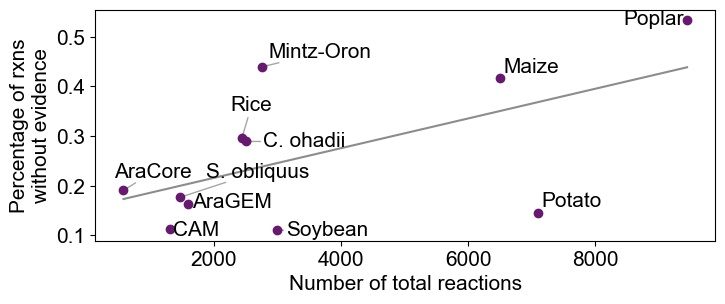

totModelRxns, evidence in 2 dbs
rho=0.648, p=0.031


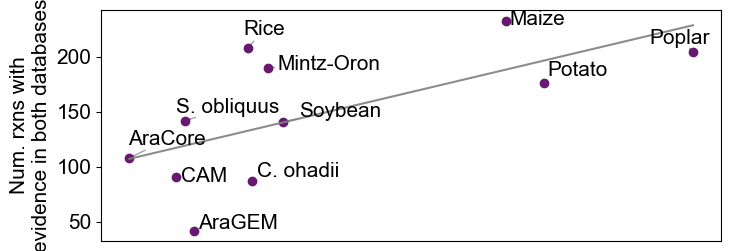

totModelRxns, evidence in 1 dbs
rho=0.728, p=0.011


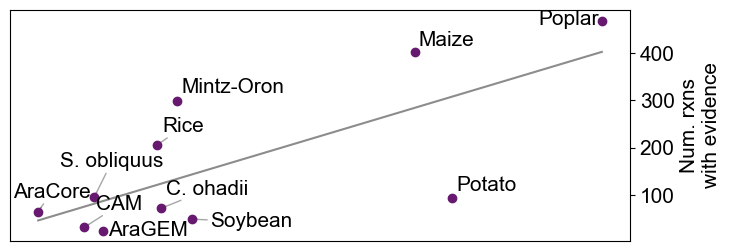

totModelRxns, evidence in 0 dbs
rho=0.724, p=0.012


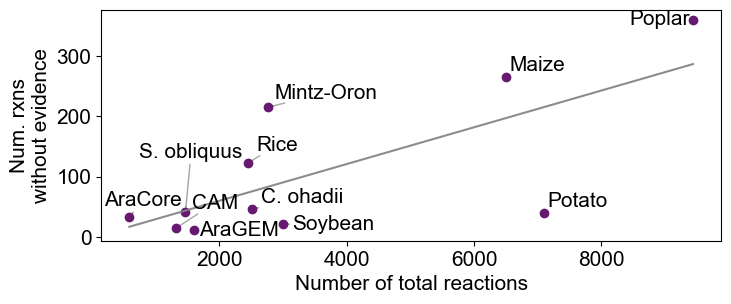

totChlRxns, percentage
rho=0.771, p=0.002


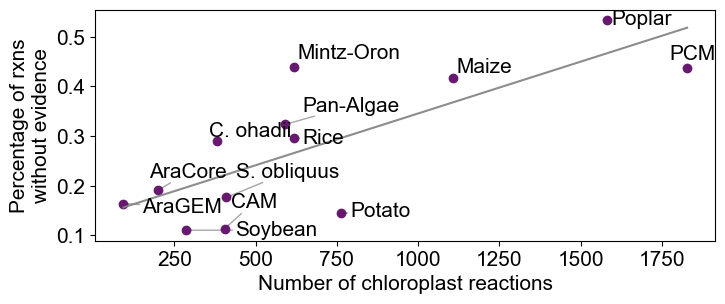

totChlRxns, evidence in 2 dbs
rho=0.86, p=0.0


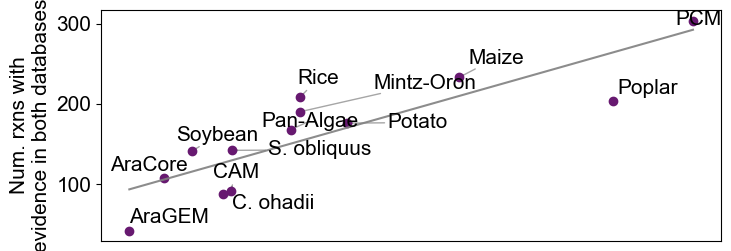

totChlRxns, evidence in 1 dbs
rho=0.938, p=0.0


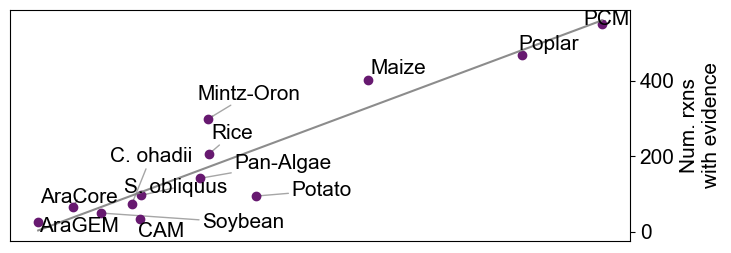

totChlRxns, evidence in 0 dbs
rho=0.929, p=0.0


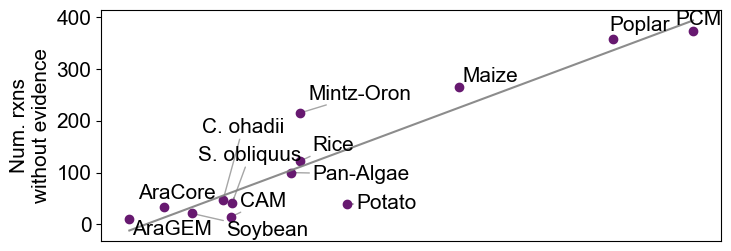

totModelRxns, percentage
rho=0.587, p=0.058


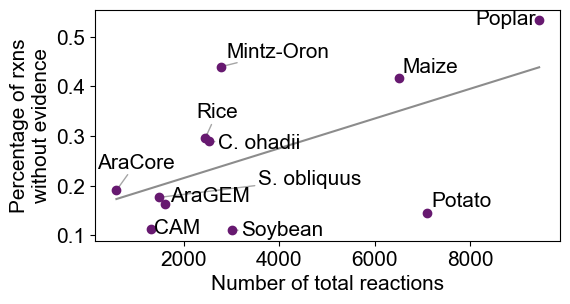

totModelRxns, evidence in 2 dbs
rho=0.648, p=0.031


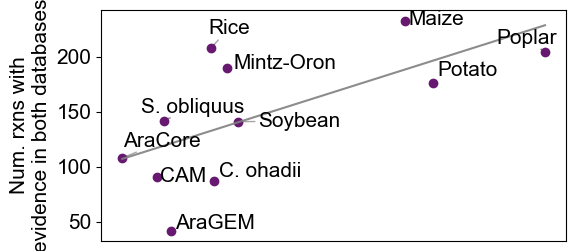

totModelRxns, evidence in 1 dbs
rho=0.728, p=0.011


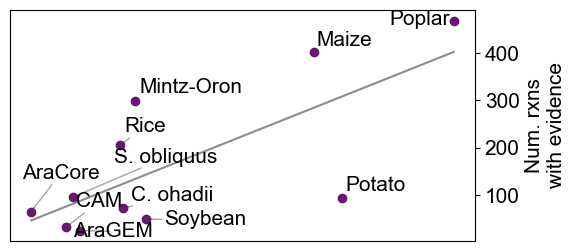

totModelRxns, evidence in 0 dbs
rho=0.724, p=0.012


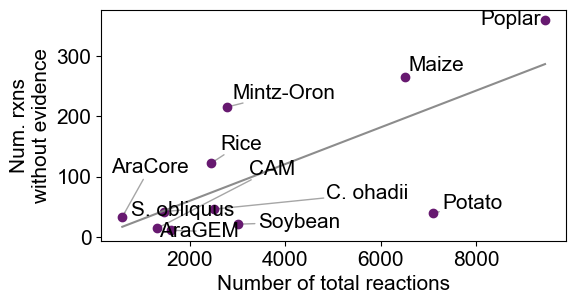

totChlRxns, percentage
rho=0.771, p=0.002


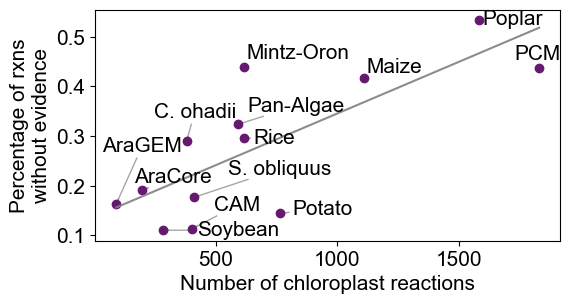

totChlRxns, evidence in 2 dbs
rho=0.86, p=0.0


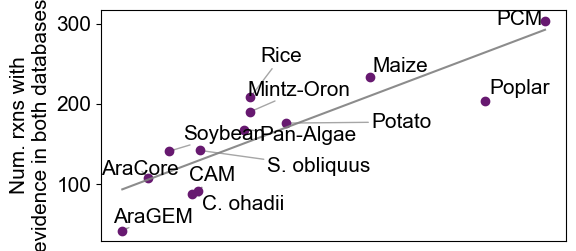

totChlRxns, evidence in 1 dbs
rho=0.938, p=0.0


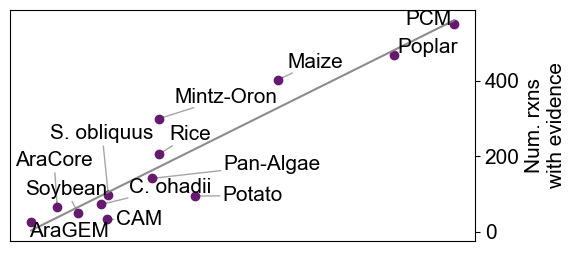

totChlRxns, evidence in 0 dbs
rho=0.929, p=0.0


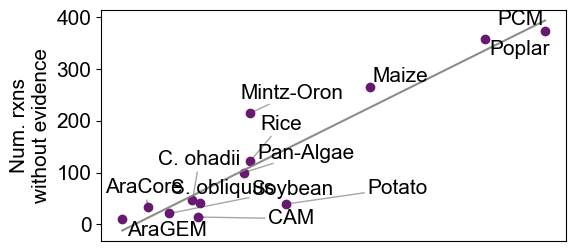

,to_reject,corrected_p,original_p,description,correlation
0,False,0.195685,0.057882,"totModelRxns, percentage",0.586516
1,False,0.120180,0.031105,"totModelRxns, evidence in 2 dbs",0.647907
2,False,0.053386,0.011062,"totModelRxns, evidence in 1 dbs",0.728130
3,False,0.053386,0.011843,"totModelRxns, evidence in 0 dbs",0.723527
4,True,0.013852,0.002049,"totChlRxns, percentage",0.770633
5,True,0.001489,0.000165,"totChlRxns, evidence in 2 dbs",0.859615
6,True,0.000057,0.000002,"totChlRxns, evidence in 1 dbs",0.938207
7,True,0.000059,0.000004,"totChlRxns, evidence in 0 dbs",0.929386
8,False,0.195685,0.057882,"totModelRxns, percentage",0.586516
9,False,0.120180,0.031105,"totModelRxns, evidence in 2 dbs",0.647907


In [13]:
# make plots and calc corr for each total number (evidence by 2, 1, 0 dbs), and for frac, with num of all and chl rxns
# make plots of corr of all and chl rxns
new_x_data = data.copy()
new_x_data['totChlRxns'] = new_x_data[['nChlRxns', 'nIntraChlTransp']].sum(axis=1)
new_x_data['model'] = data['model_name'].apply(lambda x: models_transl[x])
new_x_data.set_index('model', inplace=True)

new_y_data = plot_vals.copy()
new_y_data.columns = [models_transl[x] for x in new_y_data.columns]
perc_no_evid = new_y_data.loc[(True, 0)].divide(new_y_data.loc[True].sum()).sort_values()
y_datas = [new_y_data.loc[(True, 0)]] + \
        [new_y_data.loc[True].loc[[0,1]].sum()] + \
        [new_y_data.loc[(True, 2)]] + \
        [perc_no_evid]

ps, rhos = [], []
analysis_descriptions = []
for use_for_slides in [False, True]:
    for col in ['totModelRxns', 'totChlRxns']:
        if col == 'totModelRxns':
            pass#continue
        x_data = new_x_data[col]

        for i, y_data in list(enumerate(y_datas))[::-1]:
            analysis_descriptions.append(f'{col}, ' + (f'evidence in {i} dbs' if i < 3 else 'percentage'))
            print(analysis_descriptions[-1])
            sorted_x, sorted_y = x_data.sort_index(), y_data.sort_index()
            if col == 'totModelRxns':
                # exclude pcm and pan-algae from the data
                sorted_x = sorted_x.loc[~sorted_x.index.isin(['PCM', 'Pan-Algae'])]
                sorted_y = sorted_y.loc[~sorted_y.index.isin(['PCM', 'Pan-Algae'])]

            # correlation
            rho, p = pearsonr(sorted_x, sorted_y)
            print(f'rho={round(rho, 3)}, p={round(p, 3)}')
            ps.append(p)
            rhos.append(rho)

            # plot
            if use_for_slides:
                plt.figure(figsize = (6, 3))
            else:
                plt.figure(figsize = (8, 3))
            if i == 3:
                bbox = plt.gca().get_position()

            plt.plot(sorted_x, sorted_y, 'o', color=cols_opt_order[0])
            texts = []
            for name in sorted_x.index:
                texts.append(
                    plt.text(sorted_x.loc[name], sorted_y.loc[name], name)
                )

            # corr line
            m, b = np.polyfit(sorted_x, sorted_y, 1)
            xs = [sorted_x.min(), sorted_x.max()]
            plt.plot(xs, [m*x+b for x in xs], color = 'grey', alpha = 0.9)

            # add labels
            match i:
                case 0:
                    plt.ylabel('Num. rxns\nwithout evidence')
                case 1:
                    plt.ylabel('Num. rxns\nwith evidence')
                case 2:
                    plt.ylabel('Num. rxns with\nevidence in both databases')
                case 3:
                    plt.ylabel('Percentage of rxns\nwithout evidence')
            if i == 1:# or (col == 'totModelRxns' and i == 0):
                plt.gca().yaxis.set_label_position("right")
                plt.gca().yaxis.tick_right()
            if i != 3 and (col != 'totModelRxns' or i != 0):
                plt.tick_params(bottom = False, labelbottom = False)
            else:
                if 'Chl' in col:
                    plt.xlabel('Number of chloroplast reactions')
                else:
                    plt.xlabel('Number of total reactions')

            adjust_text(texts, expand=(1.1, 1.4), arrowprops=dict(arrowstyle='->', color='grey', alpha=0.7))
            if use_for_slides:
                savename = f'{figdir}corr_rxnEvid_nRxns_{col}_{i}_slides.png'
            else:
                savename = f'{figdir}corr_rxnEvid_nRxns_{col}_{i}.png'
            plt.savefig(savename,  dpi=300, transparent = True, bbox_inches='tight')
            plt.show()
reject, corr_p, _, _ = multipletests(ps, method='fdr_by')
pd.DataFrame({'to_reject': reject, 'corrected_p': corr_p, 'original_p': ps, 'description': analysis_descriptions, 'correlation': rhos})

In [14]:
col_order = ['nChlRxns', 'nIntraChlTransp', 'totChlRxns', 'nTransp', 'totModelRxns',  'nMetsStroma', 'nMetsThylLum', 'nMetsChl', 'nGenes', 'nSubsystems', 'nChloroplastComps', 'chlComps']
table_data = new_x_data.drop(['model_name', 'nPanGenes'], axis=1)[col_order].copy()

publish_col_names = {'nChlRxns': 'Number of non-transporting chloroplast reactions',
                    'totModelRxns': 'Number of reactions of full model',
                    'nTransp': 'Number of chloroplast-cytosol transporters',
                    'nIntraChlTransp': 'Number of Intra-chloroplast transporters',
                    'nMetsStroma': 'Number of stroma metabolites',
                    'nMetsThylLum': 'Number of thylakoid metabolites',
                    'nMetsChl': 'Total number of chloroplast metabolites',
                    'nGenes': 'Number genes mapped to chloroplast reactions',
                    'nSubsystems': 'Number of subsystem definitions',
                    'nChloroplastComps': 'Number of chloroplast compartments',
                    'chlComps': 'Chloroplast compartment IDs',
                    'totChlRxns': 'Number of reactions of chloroplast model'}
table_data.columns = [publish_col_names[col] for col in table_data.columns]
table_data['Fraction of reactions without database evidence'] = perc_no_evid
table_data['Fraction of reactions without database evidence normalized by number of reactions'] = \
    table_data['Fraction of reactions without database evidence'].divide(
        table_data['Number of reactions of chloroplast model']
    )
table_data['DOI'] = {'AraGEM': '10.1104/pp.109.148817',
                     'C. ohadii': '10.1111/nph.70528',
                     'CAM': '10.1038/s41477-018-0112-2',
                     'AraCore': '10.1104/pp.114.235358',
                     'Soybean': '10.1104/pp.19.00122',
                     'S. obliquus': '10.1021/acssynbio.3c00516',
                     'Pan-Algae': '10.1371/journal.pone.0229408',
                     'Potato': '10.1073/pnas.2502160122',
                     'Mintz-Oron': '10.1073/pnas.1100358109',
                     'Poplar': '10.1111/tpj.14746',
                     'Rice': '10.1104/pp.15.01379',
                     'Maize': '10.3389/fpls.2015.00142',
                     'PCM': 'This manuscript',
                     }
table_data.to_csv(f'{wd}Data/supplementary/supp2.csv')

### Read in soybean model with cobrapy to get compartment information
See chloroplastComparison.m

In [2]:
with silence():
    soy = cobra.io.read_sbml_model(f'{wd}Data/comparison_models/soybean.xml')
    
def reformat_met(met):
    sep_pos = met.id.rfind('_')
    base, comp = met.id[:sep_pos], met.id[sep_pos+1:]
    return f'{base}[{comp}]'

with open(f'{wd}Data/comparison_models/soy_metabolites.txt', 'w') as file:
    for m in soy.metabolites:
        file.write(reformat_met(m))
        file.write('\n')